<a href="https://colab.research.google.com/github/Yongyong-2/Quantum-Computing-Practice/blob/main/Module01_Single_Qubit_gate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bloch Sphere (블로흐 구)

### 개념

Bloch Sphere는 **1개의 큐비트(Pure State)**를 3차원 구(Sphere) 위의 한 점으로 표현하는 방법이다.

모든 Single Qubit State는 Bloch Sphere의 한 점과 일대일 대응된다.

---

### 일반적인 큐비트 상태

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle
$$

여기서

* $\alpha,\beta$ : 복소수
* $|\alpha|^2+|\beta|^2=1$

전역 위상(Global Phase)은 물리적으로 의미가 없으므로, 하나의 큐비트는 최종적으로 **2개의 자유도**만 가지며 이를 구 위의 한 점으로 표현할 수 있다.

---

### 주요 상태

* 북극(North Pole) : $|0\rangle$
* 남극(South Pole) : $|1\rangle$
* 적도(Equator) : 중첩 상태

대표적인 상태

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

$$
|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}
$$

---

### Bloch Sphere와 게이트

양자게이트는 **Bloch Sphere 위에서 상태를 회전시키는 연산**으로 이해할 수 있다.

* X Gate : X축 기준 180° 회전
* Y Gate : Y축 기준 180° 회전
* Z Gate : Z축 기준 180° 회전 (위상 변화)
* $R_x(\theta)$ : X축 기준 $\theta$만큼 회전
* $R_y(\theta)$ : Y축 기준 $\theta$만큼 회전
* $R_z(\theta)$ : Z축 기준 $\theta$만큼 회전
* Hadamard Gate : 특정 축을 기준으로 180° 회전하여 $|0\rangle \leftrightarrow |+\rangle$ 등을 변환

---

### 위상(Phase)

Bloch Sphere에서 위상의 변화는 **구의 적도 방향으로 회전하는 것**으로 이해할 수 있다.

측정 확률은 변하지 않지만, 이후 다른 게이트를 통과할 때 **간섭(Interference)** 결과를 변화시킨다.

---

### 핵심 정리

* Bloch Sphere는 **Single Qubit**만 표현할 수 있다.
* 양자게이트는 Bloch Sphere에서의 **회전(Rotation)** 이다.
* 상태의 이동은 벡터의 회전으로 해석할 수 있다.
* 위상은 측정 확률보다 **간섭 현상**에서 중요한 역할을 한다.
* Bell State와 같은 **얽힘 상태(Entangled State)** 는 하나의 Bloch Sphere로 표현할 수 없다.


In [1]:
!pip install Qiskit qiskit_aer pylatexenc

In [2]:
from qiskit import QuantumCircuit

In [4]:
qc = QuantumCircuit(1)
qc.id(0)
print(qc)

   ┌───┐
q: ┤ I ├
   └───┘


In [9]:
qc = QuantumCircuit(1)
qc.x(0)
print(qc)

   ┌───┐
q: ┤ X ├
   └───┘


In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1, 1)

# ===== Gate =====
qc.h(0)
# ================

# 측정 전 상태
print("=== Circuit ===")
print(qc.draw("text"))

print("\n=== Statevector ===")
print(Statevector.from_instruction(qc))

# 측정
qc.measure(0, 0)

sim = AerSimulator()
result = sim.run(qc, shots=1000).result()

print("\n=== Measurement ===")
print(result.get_counts())

=== Circuit ===
     ┌───┐
  q: ┤ H ├
     └───┘
c: 1/═════
          

=== Statevector ===
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

=== Measurement ===
{'1': 482, '0': 518}


In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1, 1)

# ===== Gate =====
qc.x(0)
# ================

# 측정 전 상태
print("=== Circuit ===")
print(qc.draw("text"))

print("\n=== Statevector ===")
print(Statevector.from_instruction(qc))

# 측정
qc.measure(0, 0)

sim = AerSimulator()
result = sim.run(qc, shots=1000).result()

print("\n=== Measurement ===")
print(result.get_counts())

=== Circuit ===
     ┌───┐
  q: ┤ X ├
     └───┘
c: 1/═════
          

=== Statevector ===
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

=== Measurement ===
{'1': 1000}


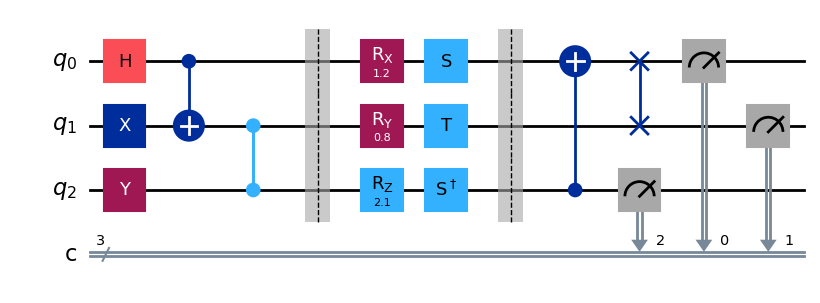

In [5]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 3)

qc.h(0)
qc.x(1)
qc.y(2)

qc.cx(0, 1)
qc.cz(1, 2)

qc.barrier()

qc.rx(1.2, 0)
qc.ry(0.8, 1)
qc.rz(2.1, 2)

qc.s(0)
qc.t(1)
qc.sdg(2)

qc.barrier()

qc.cx(2, 0)
qc.swap(0, 1)

qc.measure([0, 1, 2], [0, 1, 2])

qc.draw("mpl")

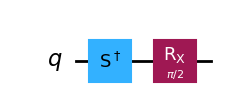

Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

qc = QuantumCircuit(1)

# ===== Basic Gates =====
# qc.id(0)          # Identity
# qc.x(0)           # Pauli-X
# qc.y(0)           # Pauli-Y
# qc.z(0)           # Pauli-Z
# qc.h(0)           # Hadamard
# qc.s(0)           # S Gate
qc.sdg(0)         # S†
# qc.t(0)           # T Gate
# qc.tdg(0)         # T†

# ===== Rotation Gates =====
qc.rx(np.pi/2, 0)    # Rx(π/2)
# qc.ry(np.pi/2, 0)    # Ry(π/2)
# qc.rz(np.pi/2, 0)    # Rz(π/2)

# ===== General Gates =====
# qc.sx(0)          # √X
# qc.sxdg(0)        # √X†
# qc.p(1.57, 0)     # Phase Gate
# qc.u(1.2, 0.5, 0.3, 0)   # Universal Gate

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

print(state)